In [2]:
import pandas as pd
df = pd.read_csv("../data/transactions.csv")


In [3]:
df

,transaction_id,amount,merchant,type,is_fraud
0,1,500,Amazon,Shopping,0
1,2,25000,ATM,Cash,1
2,3,1200,Netflix,Subscription,0
3,4,45000,Unknown,Transfer,1
4,5,800,Uber,Travel,0
5,6,35000,ATM,Cash,1
6,7,200,Swiggy,Food,0
7,8,40000,Unknown,Transfer,1
8,9,950,Amazon,Shopping,0
9,10,27000,ATM,Cash,1


In [4]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   transaction_id  10 non-null     int64
 1   amount          10 non-null     int64
 2   merchant        10 non-null     str  
 3   type            10 non-null     str  
 4   is_fraud        10 non-null     int64
dtypes: int64(3), str(2)
memory usage: 532.0 bytes


In [5]:
df.describe()

,transaction_id,amount,is_fraud
count,10.00000,10.000000,10.000000
mean,5.50000,17565.000000,0.500000
std,3.02765,18624.894481,0.527046
min,1.00000,200.000000,0.000000
25%,3.25000,837.500000,0.000000
50%,5.50000,13100.000000,0.500000
75%,7.75000,33000.000000,1.000000
max,10.00000,45000.000000,1.000000


In [6]:
df.isnull().sum()

transaction_id    0
amount            0
merchant          0
type              0
is_fraud          0
dtype: int64

In [7]:
df["amount"]

0      500
1    25000
2     1200
3    45000
4      800
5    35000
6      200
7    40000
8      950
9    27000
Name: amount, dtype: int64

In [8]:
df["merchant"]

0     Amazon
1        ATM
2    Netflix
3    Unknown
4       Uber
5        ATM
6     Swiggy
7    Unknown
8     Amazon
9        ATM
Name: merchant, dtype: str

In [9]:
df[df["is_fraud"]==1]

,transaction_id,amount,merchant,type,is_fraud
1,2,25000,ATM,Cash,1
3,4,45000,Unknown,Transfer,1
5,6,35000,ATM,Cash,1
7,8,40000,Unknown,Transfer,1
9,10,27000,ATM,Cash,1


In [10]:
df[df["is_fraud"]==0]

,transaction_id,amount,merchant,type,is_fraud
0,1,500,Amazon,Shopping,0
2,3,1200,Netflix,Subscription,0
4,5,800,Uber,Travel,0
6,7,200,Swiggy,Food,0
8,9,950,Amazon,Shopping,0


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


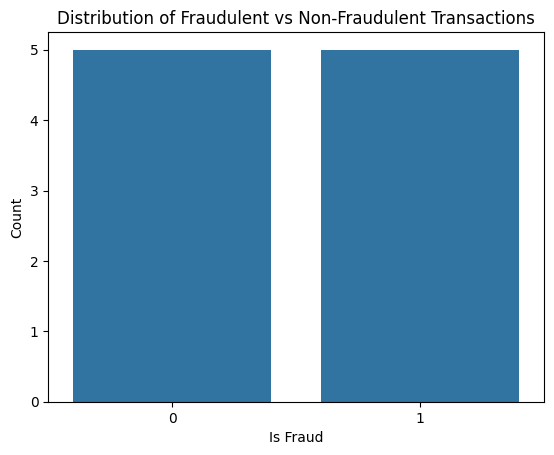

In [12]:
sns.countplot(x="is_fraud", data=df)
plt.title("Distribution of Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

Text(0.5, 1.0, 'Distribution of Transaction Amounts')

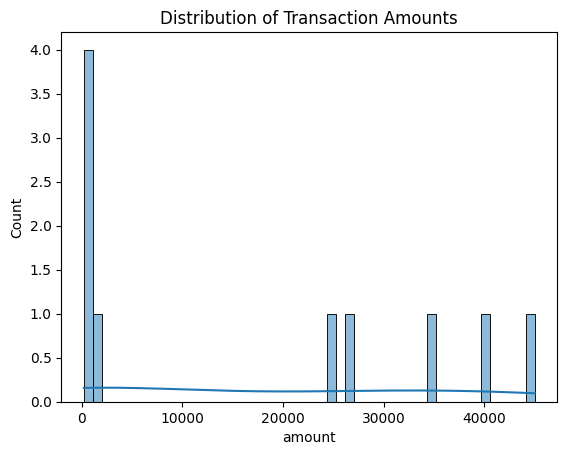

In [13]:
sns.histplot(df["amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")        

<Axes: xlabel='is_fraud', ylabel='amount'>

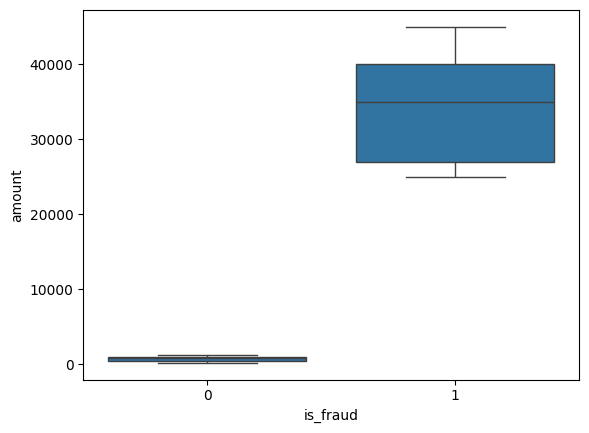

In [14]:
sns.boxplot(
    x="is_fraud",
    y="amount",
    data=df
)

In [15]:
df.to_csv(
    "../data/processed.csv",
    index=False
)

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("../data/transactions.csv")
df.head()

,transaction_id,amount,merchant,type,is_fraud
0,1,500,Amazon,Shopping,0
1,2,25000,ATM,Cash,1
2,3,1200,Netflix,Subscription,0
3,4,45000,Unknown,Transfer,1
4,5,800,Uber,Travel,0


In [3]:
le = LabelEncoder()
df["merchant"] = le.fit_transform(df["merchant"])
df["type"] = le.fit_transform(df["type"])


In [4]:
df.head()

,transaction_id,amount,merchant,type,is_fraud
0,1,500,1,2,0
1,2,25000,0,0,1
2,3,1200,2,3,0
3,4,45000,5,4,1
4,5,800,4,5,0


In [5]:
x = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model.fit(x_train, y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [11]:
predictions = model.predict(
    x_test
)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.50


In [12]:
import joblib

In [13]:
joblib.dump(
    model,
    "../models/xgboost_fraud.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: '../models/xgboost_fraud.pkl'